In [28]:
from typing import TypedDict , List
import re

from dotenv import load_dotenv

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage , SystemMessage , HumanMessage
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings

from langgraph.graph import START , END , StateGraph
from pydantic import  BaseModel

In [29]:
load_dotenv()

True

In [4]:
docs = (
    PyPDFLoader("./documents/book1.pdf").load()
    + PyPDFLoader("./documents/book2.pdf").load()
    + PyPDFLoader("./documents/book3.pdf").load()
)

In [6]:
len(docs)

2123

In [30]:
chunks=RecursiveCharacterTextSplitter(chunk_size=900 , chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content=d.page_content.encode("utf-8",'ignore').decode("utf-8",'ignore')
    

In [12]:
embeddings=HuggingFaceEmbeddings(model='all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9622.32it/s]


In [31]:
vector_store=FAISS.from_documents(chunks,embeddings)
retriever=vector_store.as_retriever(serch_type='similarity',search_kwargs={'k':4})
llm=ChatGroq(model='openai/gpt-oss-120b')

In [32]:
class State(TypedDict):
    questions:str
    docs:List[Document]
    strips:List[str]
    kept_string:List[str]
    refined_context:str
    answer:str

In [33]:
def retrieve(state:State)->State:
    q=state['questions']
    return {'docs':retriever.invoke(q)}


In [34]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [35]:
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


In [36]:
def refine(state: State) -> State:

    q = state["questions"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [37]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["questions"], "refined_context": state['refined_context']})
    return {"answer": out.content}

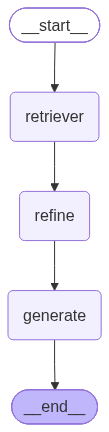

In [38]:
g = StateGraph(State)
g.add_node("retriever", retrieve)
g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retriever")
g.add_edge("retriever", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app


In [40]:
res = app.invoke({
    "questions": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

- The expected loss can be written as the sum of three parts: a squared‑bias term, a variance term, and a constant noise term.  
- **Very flexible models** (small regularisation coefficient λ) can fit the training data closely, which makes the **bias low** (the average prediction \(y(x)\) is close to the true function \(h(x)\)) but causes the predictions to vary a lot from one data set to another, giving a **high variance**.  
- **Rigid models** (large λ) are constrained, so the predictions from different data sets look similar (low variance), but they cannot capture the true underlying pattern well, resulting in a **high bias**.  
- Because bias and variance move in opposite directions as λ changes, there is a **trade‑off**: decreasing λ reduces bias but increases variance, while increasing λ reduces variance but raises bias.  
- The optimal predictive model is the one that balances these two effects. In the example, the quantity \((\text{bias})^{2}+\text{variance}\) reaches its minim

In [41]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

3.2. The Bias-Variance Decomposition 151
Figure 3.6 Plot of squared bias and variance,
together with their sum, correspond-
ing to the results shown in Fig-
ure 3.5. Also shown is the average
test set error for a test data set size
of 1000 points. The minimum value
of (bias)2 + variance occurs around
ln λ = −0.31, which is close to the
value that gives the minimum error
on the test data.
lnλ
−3 −2 −1 0 1 2
0
0.03
0.06
0.09
0.12
0.15
(bias)2
variance
(bias)2 + variance
test error
ﬁt a model with 24 Gaussian basis functions by minimizing the regularized error
function (3.27) to give a prediction function y(l)(x) as shown in Figure 3.5. The
top row corresponds to a large value of the regularization coefﬁcientλ that gives low
variance (because the red curves in the left plot look similar) but high bias (because
****************************************************************************************************
with respect to multiple data sets.
We can also examine the bias-variance trade-